<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Joint Model Specification

$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

#### NLMEM Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [3]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class LogisticMixedEffectsModel(AbstractMixedEffectsModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_N{self.N}_J{self.J}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""

        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                asymptotic=pc.RealPositive(scale=100),
                inflexion=pc.Real(loc=100, scale=100),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(200, 200)),
            var_residual=pc.RealPositive(scale=100),
        )

        AbstractMixedEffectsModel.init(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = asymptotic
        phi2 = inflexion
        """

        out = phi1[:, None] / (1 + jnp.exp(-(times - phi2[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1500, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time
        )

        return {"mem_obs_time": time} | obs, sim

joint model with coxModel is all ready implement in sdg4varselect for all MixedEffectsModel

In [4]:
from sdg4varselect.models import WeibullCoxJM


def jointModel(N, J, P):
    return WeibullCoxJM(
        mem=LogisticMixedEffectsModel(N=N, J=J), P=P, alpha_scale=0.001, a=800, b=10
    )

In [5]:
import pandas as pd
from sdg4varselect.outputs import TestResults

seed_name = "S(1, 100)"

results = TestResults(
    [
        TestResults.load(jointModel(400, 15, 500), "files", filename_add_on=seed_name),
        TestResults.load(jointModel(200, 15, 500), "files", filename_add_on=seed_name),
        TestResults.load(jointModel(200, 15, 200), "files", filename_add_on=seed_name),
        TestResults.load(jointModel(200, 15, 300), "files", filename_add_on=seed_name),
        TestResults.load(
            jointModel(200, 15, 800), "files", filename_add_on="S(74, 77)"
        ),
    ],
    [
        {"N": 400, "J": 15, "P": 500},
        {"N": 200, "J": 15, "P": 500},
        {"N": 200, "J": 15, "P": 200},
        {"N": 200, "J": 15, "P": 300},
        {"N": 200, "J": 15, "P": 800},
    ],
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])


pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


files/WCoxMemJM_N400_J15_P500_S(1, 100) LOADED !
files/WCoxMemJM_N200_J15_P500_S(1, 100) LOADED !
files/WCoxMemJM_N200_J15_P200_S(1, 100) LOADED !
files/WCoxMemJM_N200_J15_P300_S(1, 100) LOADED !
files/WCoxMemJM_N200_J15_P800_S(74, 77) LOADED !
chrono = ['10:36:49.969583', '3 days, 9:06:41.985548', '3 days, 1:48:14.364397', '1:50:36.802613', '3:15:32.025801']
[4, 4, 4, 4, 4]


,by fit,by estimation ( 20.0 fits)
"N = 400, P = 500",0:07:57.624620,1:03:40.996958
"N = 200, P = 500",1:00:50.024819,8:06:40.198555
"N = 200, P = 200",0:55:21.179555,7:22:49.436440
"N = 200, P = 300",0:01:22.960033,0:11:03.680261
"N = 200, P = 800",0:02:26.650323,0:19:33.202580


In [6]:
myModel = jointModel(200, 15, P=max([c["P"] for c in results.config]))

p_star = myModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=10,
    alpha=0.05,
    beta=jnp.concatenate(
        [jnp.array([-3, -2, 2, 3]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)

Vérification de la réparition des estimations par rapport à la vraissemblance

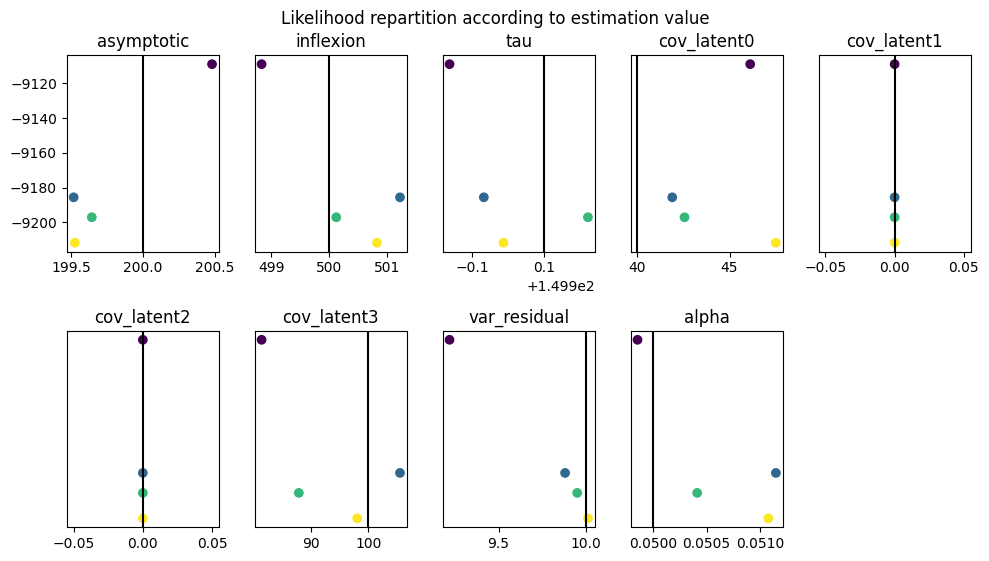

In [7]:
fig = sdgplt.figure(height=8, width=10)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD].T,
    results[-1].likelihood[:, 1],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=3,
    ncols=5,
    fig=fig,
)

fig.tight_layout()

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

Regularization path check

In [8]:
@sdgplt.add_figure
def _plot_bic(
    ax,
    lbd_set,
    bic,
    argmin_bic,
    colors=["k", "w", "b"],
    msg="BIC",
    fig=None,
):
    ax_bic = ax.twinx()
    ax_bic.plot(lbd_set, bic, color=colors[0], linewidth=5, linestyle="-")
    ax_bic.plot(lbd_set, bic, color=colors[1], linewidth=3, linestyle="-")
    ax_bic.plot(lbd_set, bic, color=colors[0], linewidth=2, linestyle="--", label=msg)
    ax_bic.set(ylabel="BIC Score")

    # minimum value of bic
    sdgplt.plot_axvline(
        ax_bic, lbd_set, bic, i=argmin_bic, color=colors[2], msg=" = min({msg})"
    )

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


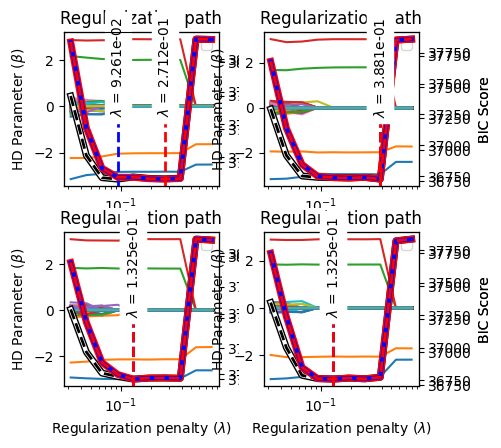

In [10]:
from sdg4varselect._regularization_function import eBIC

step = 1

fig = sdgplt.figure(4, 4)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        reg = results[0][i * subfigs.shape[0] + j]

        x = jnp.array([r.last_theta[step, myModel.DIM_LD :] for r in reg])
        t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

        ebic = eBIC(
            t,
            jnp.array([r.likelihood[step] for r in reg]),
            myModel.N * (1 + myModel.J),
        )

        multi_theta_hd = [res[step].last_theta[myModel.DIM_LD :] for res in reg]

        ax = subfigs[i][j].add_subplot(1, 1, 1)
        ax.set_title("Regularization path")
        ax.set_xlabel(r"Regularization penalty ($\lambda$)")
        ax.set_ylabel(r"HD Parameter ($\beta$)")

        ax.set_xscale("log")

        ax.plot(reg.lbd_set, x)

        _plot_bic(
            ax=ax,
            lbd_set=reg.lbd_set,
            bic=reg.bic[step],
            argmin_bic=jnp.argmin(reg.bic[step]),
        )

        _plot_bic(
            ax=ax,
            lbd_set=reg.lbd_set,
            bic=ebic,
            argmin_bic=jnp.argmin(ebic),
            colors=["r", "b", "r"],
            msg=eBIC,
        )

        ax.legend()

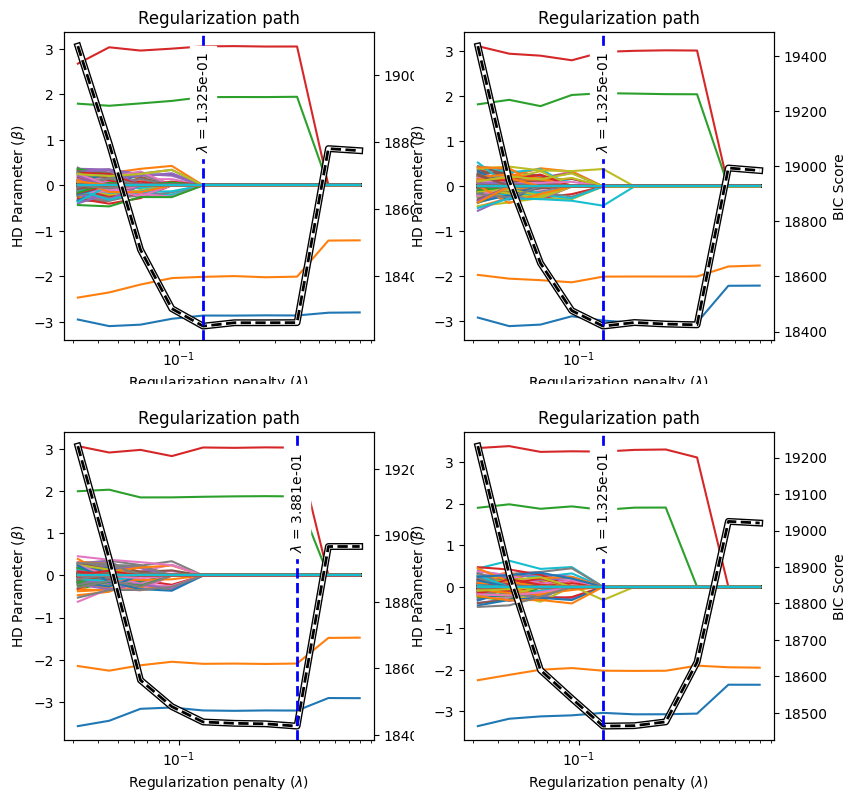

In [11]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        sdgplt.plot_reg_path(
            reg_res=results[-1][i * subfigs.shape[0] + j],
            dim_ld=myModel.DIM_LD,
            fig=subfig,
        )

/tmp/ipykernel_467/3624330667.py:35: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()


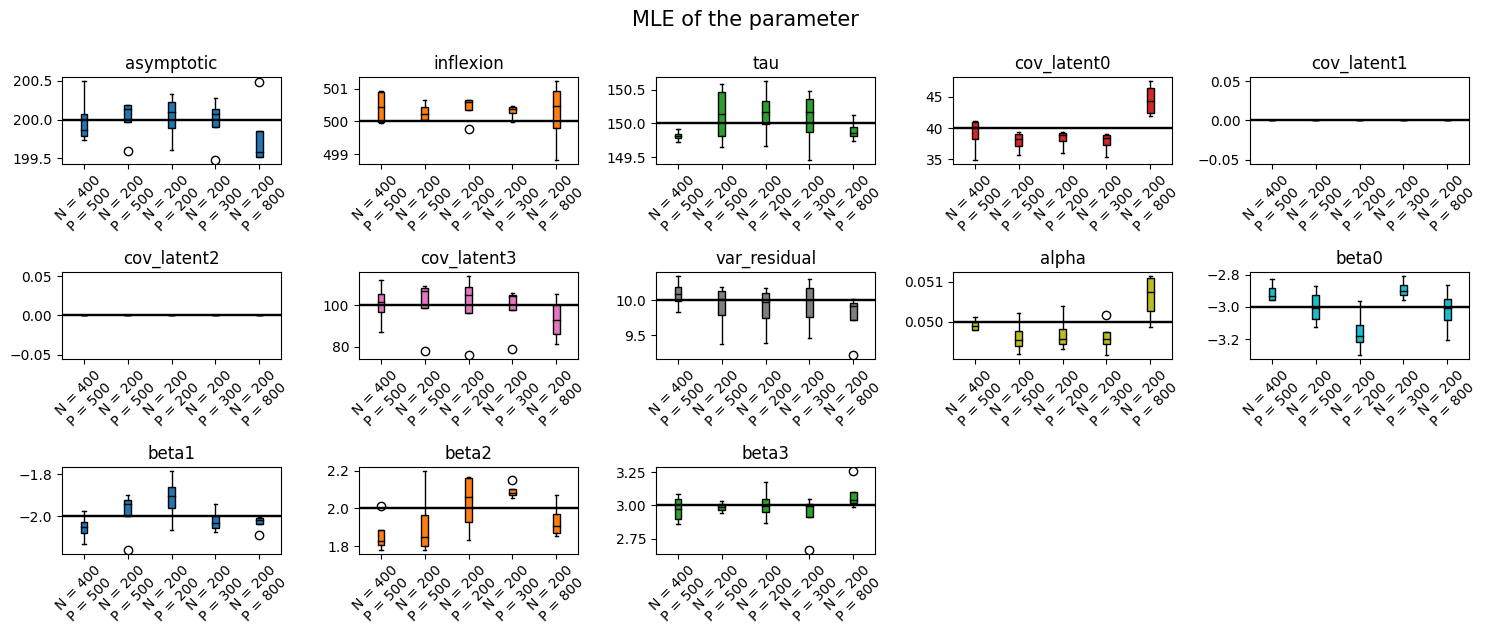

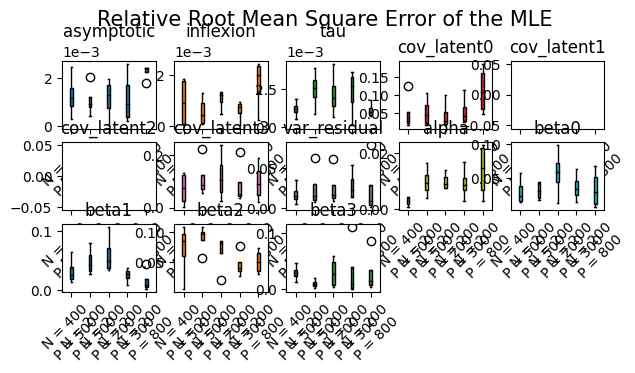

In [12]:
scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(
        results.get_scenarios_labels("N"), results.get_scenarios_labels("P")
    )
]
x = results.last_theta[:, :, 1, : myModel.DIM_LD + 4]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myModel.hstack_params(p_star)[: myModel.DIM_LD + 4],
    xlabels=scenarios_labels,
    title=myModel.params_names[: myModel.DIM_LD + 4],
    nrows=3,
    ncols=5,
    fig=sdgplt.figure(height=6, width=15),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

x = jnp.abs((1 - x / myModel.hstack_params(p_star)[: myModel.DIM_LD + 4]))
fig = sdgplt.boxplot_estimation(
    x=x.T,
    xlabels=scenarios_labels,
    title=myModel.params_names[: myModel.DIM_LD + 4],
    nrows=3,
    ncols=5,
    fig=sdgplt.figure(height=3, width=7),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("Relative Root Mean Square Error of the MLE", fontsize=15, y=1.05)

## RMSE estimation P = 500

In [13]:
import numpy as np


def table_rmse_article(results):
    # last_theta_estim =
    params_names = np.array(
        [
            "$\mu_1$",
            "$\mu_2$",
            "$\\tau$",
            "$\gamma^2_1$",
            "$\gamma^2_12$",
            "$\gamma^2_21$",
            "$\gamma^2_2$",
            "$\sigma^2$",
            "$\\alpha$",
        ]
        + [f"$\\beta_{i+1}$" for i in range(myModel.P)]
    )

    df = []
    for i in range(len(results)):
        pd_df = sdgplt.get_dataframe_results(
            results[i].last_theta[
                :, -1, : myModel.DIM_LD + 4
            ],  # last_theta_estim[:, : myModel.DIM_LD],
            myModel.hstack_params(p_star)[: myModel.DIM_LD + 4],
            params_names[: myModel.DIM_LD + 4],
        )

        pd_df = pd_df.drop("real value", axis=1)
        # pd_df = pd_df.drop("RRMSE", axis=1)
        # pd_df= pd_df.drop("RMSE", axis = 1)
        pd_df = pd_df.drop("mean", axis=1)
        pd_df = pd_df.drop("variance", axis=1)

        df.append(pd_df)

    col = pd.MultiIndex.from_arrays(
        [
            np.repeat([f'{c["N"]}' for c in results.config], len(pd_df.index)),
            np.tile(pd_df.index, len(results)),
        ]
    )
    col = sum([[l, l] for l in results.get_scenarios_labels("N")], [])

    pd_df = pd.concat(df, axis=1)
    print(pd_df.index)

    pd_df = pd.DataFrame(
        pd_df.to_numpy(),
        columns=pd.MultiIndex.from_arrays(
            [
                np.repeat([f" P = {results.config[0]['P']}"], len(pd_df.columns)),
                col,  # pd_df.columns,
            ]
        ),
        index=pd_df.index,
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    return pd_df.style.format("{:.2f}".format)


table_rmse_article(results.filter(P=500).sort("N"))

Index(['$\mu_1$', '$\mu_2$', '$\tau$', '$\gamma^2_1$', '$\gamma^2_2$',
       '$\sigma^2$', '$\alpha$', '$\beta_1$', '$\beta_2$', '$\beta_3$',
       '$\beta_4$'],
      dtype='object')
\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{4}{r}{ P = 500} \\
 & N = 200 & N = 200 & N = 400 & N = 400 \\
\midrule
$\mu_1$ & 0.247 & 0.124 & 0.299 & 0.149 \\
$\mu_2$ & 0.381 & 0.076 & 0.633 & 0.127 \\
$\tau$ & 0.407 & 0.271 & 0.195 & 0.130 \\
$\gamma^2_1$ & 2.524 & 6.309 & 2.649 & 6.623 \\
$\gamma^2_2$ & 12.949 & 12.949 & 9.018 & 9.018 \\
$\sigma^2$ & 0.334 & 3.339 & 0.204 & 2.037 \\
$\alpha$ & 0.001 & 1.091 & 0.000 & 0.317 \\
$\beta_1$ & 0.099 & 3.309 & 0.104 & 3.450 \\
$\beta_2$ & 0.104 & 5.181 & 0.076 & 3.777 \\
$\beta_3$ & 0.185 & 9.230 & 0.163 & 8.139 \\
$\beta_4$ & 0.036 & 1.191 & 0.095 & 3.164 \\
\bottomrule
\end{tabular}



### Variable selection numerical proof

In [14]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)
print(multi_support.shape)

(5, 4, 800)
(5, 4, 800)


[[4. 4. 4. 4.]
 [4. 4. 4. 4.]
 [4. 4. 4. 4.]
 [4. 6. 4. 5.]]


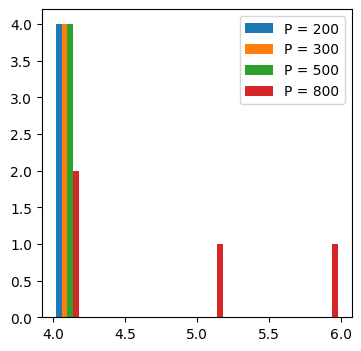

In [15]:
def hist(results):
    support_star = get_support_star(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    multi_support = get_support(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )
    ax = sdgplt.get_ax(4, 4)
    print(jnp.nansum(multi_support, axis=-1))
    h = ax.hist(
        jnp.nansum(multi_support, axis=-1), label=results.get_scenarios_labels("P")
    )
    ax.legend()


hist(results.filter(N=200).sort("P"))

In [ ]:
jnp.nansum(jnp.nanmean(multi_support, axis=1), axis=1)

In [16]:
def table_accuracy_article(results):

    support_star = get_support_star(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    multi_support = get_support(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    ds = jnp.abs(multi_support - support_star)
    # TP/total P
    TP = jnp.nansum(ds[:, :, :3], axis=-1)
    sensitivity = 1 - jnp.nanmean(ds[:, :, :3], axis=-1)
    # TN / total N
    TN = jnp.nansum(ds[:, :, 3:], axis=-1)
    specificity = 1 - jnp.nanmean(ds[:, :, 3:], axis=-1)
    # (TP+TN)/dim
    accuracy = 1 - jnp.nansum(ds, axis=-1)
    accuracy = 1 - jnp.nanmean(ds, axis=-1)

    dx = jnp.abs(results.last_theta[:, :, -1, myModel.DIM_LD :] - p_star.beta)
    L1 = jnp.nansum(dx, axis=-1)
    L2 = jnp.sqrt(jnp.nansum(dx**2, axis=-1))

    x = jnp.array([sensitivity, specificity, accuracy, L1, L2])
    y = [x.mean(axis=-1), jnp.sqrt(x.var(axis=-1))]
    df = jnp.column_stack(
        [jnp.column_stack([y[0][i], y[1][i]]) for i in range(x.shape[0])]
    )
    df = jnp.concatenate([jnp.stack([y[0].T[i], y[1].T[i]]) for i in range(x.shape[1])])

    col = [
        "sensitivity",
        "specificity",
        "accuracy",
        "L1",
        "L2",
    ]
    # col = pd.MultiIndex.from_arrays(
    #     [ sum([[i]*2 for i in range(5)],[]),
    #         ["mean", "var"] * 5,
    #     ]
    # )

    pd_df = pd.DataFrame(
        df,
        columns=col,
        index=sum([[f'N = {c["N"]}, P = {c["P"]}', ""] for c in results.config], []),
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    # .style.format(["{:.3%}".format, "{:.1}".format]*5)
    # {
    #     "sensitivity": "{:.3%}".format,
    #     "specificity": "{:.3%}".format,
    #     "accuracy": "{:.3%}".format,
    #     "L1": "{:.1f}".format,
    #     "L2": "{:.1f}".format,
    # }
    return pd_df.style.format("{:.2}".format)


table_accuracy_article(results.filter(N=200).sort("P"))

\begin{tabular}{lrrrrr}
\toprule
 & sensitivity & specificity & accuracy & L1 & L2 \\
\midrule
N = 200, P = 200 & 1.000 & 1.000 & 1.000 & 0.509 & 0.292 \\
 & 0.000 & 0.000 & 0.000 & 0.101 & 0.057 \\
N = 200, P = 300 & 1.000 & 1.000 & 1.000 & 0.346 & 0.207 \\
 & 0.000 & 0.000 & 0.000 & 0.166 & 0.112 \\
N = 200, P = 500 & 1.000 & 1.000 & 1.000 & 0.398 & 0.233 \\
 & 0.000 & 0.000 & 0.000 & 0.067 & 0.041 \\
N = 200, P = 800 & 1.000 & 0.999 & 0.999 & 0.602 & 0.358 \\
 & 0.000 & 0.001 & 0.001 & 0.261 & 0.163 \\
\bottomrule
\end{tabular}



,sensitivity,specificity,accuracy,L1,L2
"N = 200, P = 200",1.0,1.0,1.0,0.51,0.29
,0.0,0.0,0.0,0.1,0.057
"N = 200, P = 300",1.0,1.0,1.0,0.35,0.21
,0.0,0.0,0.0,0.17,0.11
"N = 200, P = 500",1.0,1.0,1.0,0.4,0.23
,0.0,0.0,0.0,0.067,0.041
"N = 200, P = 800",1.0,1.0,1.0,0.6,0.36
,0.0,0.001,0.001,0.26,0.16


In [17]:

support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)

multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)

all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T

pd.DataFrame(score_support, col = ["Exact", "Over"], index = )


SyntaxError: invalid syntax (4249805972.py, line 13)

[[0.75 0.25]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.5  0.5 ]]


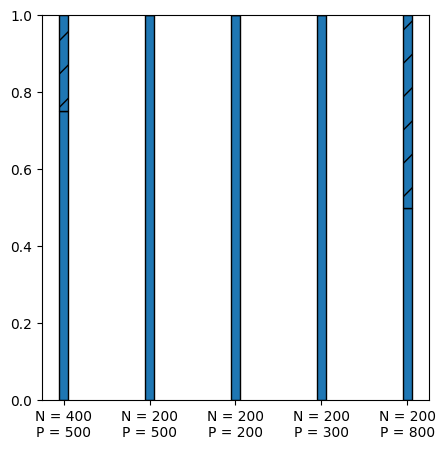

In [18]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )